# Phase 8: A correct label budget experiment

CPU only. Attach both `phase-1-sep-14` and `phase-6-sep-15`.

Phase 7 section 5 had two defects that make its guarantee claim unsound:

1. **Selection bias.** Trials where the bound accepted nothing returned NaN risk
   and were dropped. At n=100 that silently kept only the lucky trials, which is
   why coverage looked *higher* at n=100 (0.602) than at n=1000 (0.379) while
   risk looked lower. Abstaining entirely is a legitimate outcome and must be
   counted as coverage 0, not discarded.
2. **No multiplicity correction.** A Clopper-Pearson bound was evaluated at every
   candidate threshold and the best one selected. That is selection on the same
   data, so the nominal 10% was not honoured, and observed violation reached 17%.

This notebook fixes both with a Bonferroni corrected bound over a fixed grid,
which is the standard Learn-then-Test construction.

In [1]:
import glob, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import beta

F1=glob.glob("/kaggle/input/**/logits.npz",recursive=True)[0]
F2=glob.glob("/kaggle/input/**/logits2.npz",recursive=True)[0]
d1,d2=np.load(F1),np.load(F2); SEEDS=[0,1,2]; TG=0.05; ALPHA=0.10
STD15=["gaussian_noise","shot_noise","impulse_noise","defocus_blur","glass_blur",
       "motion_blur","zoom_blur","snow","frost","fog","brightness","contrast",
       "elastic_transform","pixelate","jpeg_compression"]

def softmax(z,T=1.0):
    z=z.astype(np.float64)/T; z-=z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None)).mean()
def ep(m,T): return np.mean([softmax(x,T) for x in m],0)
def rv(a): return [d2[f"wrn_val_{s}"] if a=="wrn" else d1[f"val_{s}"] for s in SEEDS]
def rc_(a,cc,sv): return [d2[f"wrn_{cc}_{sv}_{s}"] if a=="wrn" else d1[f"{cc}_{sv}_{s}"] for s in SEEDS]
Y_VAL,Y_CORR=d1["y_val"],d1["y_corr"]
T_={a:minimize_scalar(lambda t,a=a: nll(ep(rv(a),t),Y_VAL),bounds=(.5,10),method="bounded").x
    for a in ("res","wrn")}
P={(a,cc,sv):(ep(rc_(a,cc,sv),T_[a]),Y_CORR) for a in ("res","wrn") for cc in STD15 for sv in range(1,6)}
print({k:round(v,3) for k,v in T_.items()}, len(P),"cells")

{'res': np.float64(1.242), 'wrn': np.float64(1.219)} 150 cells


## 1. Learn-then-Test threshold

Fixed grid of 100 candidate thresholds, chosen before seeing any labels.
Clopper-Pearson upper bound at `ALPHA / 100` per candidate, so the family wise
error is at most `ALPHA`. Among candidates whose bound clears the target, take
the one with the highest coverage. If none clears, abstain on everything.

In [2]:
GRID=np.linspace(0.10,0.9999,100)          # fixed, data independent
ALPHA_C=ALPHA/len(GRID)

def cp_upper(k,n,al):
    if n==0: return 1.0
    return 1.0 if k==n else beta.ppf(1-al,k+1,n-k)

def ltt_threshold(pr,y,idx,target,corrected=True):
    al=ALPHA_C if corrected else ALPHA
    cf=pr[idx].max(1); wrong=pr[idx].argmax(1)!=y[idx]
    best=1.0
    for t in GRID:                              # ascending: later = stricter
        a=cf>=t
        if a.sum()==0: continue
        if cp_upper(wrong[a].sum(), a.sum(), al)<=target:
            best=t; break                       # first (loosest) that clears
    return best

def eval_thr(pr,y,thr):
    cf=pr.max(1); a=cf>=thr
    if a.sum()==0: return 0.0, 0.0, True        # risk 0, coverage 0, abstained
    return 1-(pr.argmax(1)[a]==y[a]).mean(), a.mean(), False

## 2. Corrected label budget curve

`viol` should now sit at or below 10%. `abst` is the fraction of trials that
abstained entirely, which is the honest cost of a valid guarantee at small n.

In [3]:
rng=np.random.default_rng(0); BUD=[50,100,250,500,1000,2000]; TR=20
out={}
print(f"{'arch':>4} {'sev':>3} {'n':>5} {'risk':>7} {'cov':>7} {'viol':>6} {'abst':>6}")
for a in ("res","wrn"):
    for sev in [3,5]:
        for n in BUD:
            rs,cs,vs,ab=[],[],[],[]
            for cc in STD15:
                pr,y=P[(a,cc,sev)]
                for _ in range(TR):
                    i=rng.permutation(len(y)); lab,ev=i[:n],i[n:]
                    t=ltt_threshold(pr,y,lab,TG)
                    r,cv,z=eval_thr(pr[ev],y[ev],t)
                    rs.append(r); cs.append(cv); vs.append(r>TG); ab.append(z)
            out[(a,sev,n)]=(np.mean(rs),np.mean(cs),np.mean(vs),np.mean(ab))
            print(f"{a:>4} {sev:>3} {n:>5} {np.mean(rs):>7.3f} {np.mean(cs):>7.3f} "
                  f"{np.mean(vs)*100:>5.0f}% {np.mean(ab)*100:>5.0f}%")

arch sev     n    risk     cov   viol   abst
 res   3    50   0.000   0.000     0%   100%
 res   3   100   0.000   0.000     0%   100%
 res   3   250   0.003   0.141     0%    81%
 res   3   500   0.008   0.291     0%    57%
 res   3  1000   0.016   0.419     0%    35%
 res   3  2000   0.023   0.484     0%    27%
 res   5    50   0.000   0.000     0%   100%
 res   5   100   0.000   0.000     0%   100%
 res   5   250   0.001   0.037     0%    95%
 res   5   500   0.002   0.060     0%    91%
 res   5  1000   0.005   0.104     0%    79%
 res   5  2000   0.008   0.138     0%    71%
 wrn   3    50   0.000   0.000     0%   100%
 wrn   3   100   0.000   0.000     0%   100%
 wrn   3   250   0.002   0.124     0%    83%
 wrn   3   500   0.008   0.270     0%    58%
 wrn   3  1000   0.015   0.381     0%    35%
 wrn   3  2000   0.022   0.439     0%    26%
 wrn   5    50   0.000   0.000     0%   100%
 wrn   5   100   0.000   0.000     0%   100%
 wrn   5   250   0.001   0.027     0%    96%
 wrn   5  

## 3. Cost of validity

Compare against the uncorrected version from Phase 7. If correction buys a valid
guarantee at the price of some coverage, quantify that price. That tradeoff is
the paper's practical recommendation.

In [4]:
print(f"{'arch':>4} {'sev':>3} {'n':>5} {'corrected':>22} {'uncorrected':>22}")
print(f"{'':>4} {'':>3} {'':>5} {'risk':>7}{'cov':>7}{'viol':>8} {'risk':>7}{'cov':>7}{'viol':>8}")
for a in ("res","wrn"):
    for sev in [5]:
        for n in [100,500,2000]:
            for corr in (True,False):
                rs,cs,vs=[],[],[]
                for cc in STD15:
                    pr,y=P[(a,cc,sev)]
                    for _ in range(TR):
                        i=rng.permutation(len(y))
                        t=ltt_threshold(pr,y,i[:n],TG,corrected=corr)
                        r,cv,_=eval_thr(pr[i[n:]],y[i[n:]],t); rs.append(r); cs.append(cv); vs.append(r>TG)
                if corr: A=(np.mean(rs),np.mean(cs),np.mean(vs))
                else:    B=(np.mean(rs),np.mean(cs),np.mean(vs))
            print(f"{a:>4} {sev:>3} {n:>5} {A[0]:>7.3f}{A[1]:>7.3f}{A[2]*100:>7.0f}% "
                  f"{B[0]:>7.3f}{B[1]:>7.3f}{B[2]*100:>7.0f}%")

arch sev     n              corrected            uncorrected
                  risk    cov    viol    risk    cov    viol
 res   5   100   0.000  0.000      0%   0.003  0.057      2%
 res   5   500   0.002  0.060      0%   0.010  0.150      3%
 res   5  2000   0.008  0.143      0%   0.018  0.205      4%
 wrn   5   100   0.000  0.000      0%   0.002  0.050      1%
 wrn   5   500   0.001  0.052      0%   0.011  0.138      3%
 wrn   5  2000   0.008  0.122      0%   0.018  0.180      3%


## 4. Figure: coverage recovered against label budget

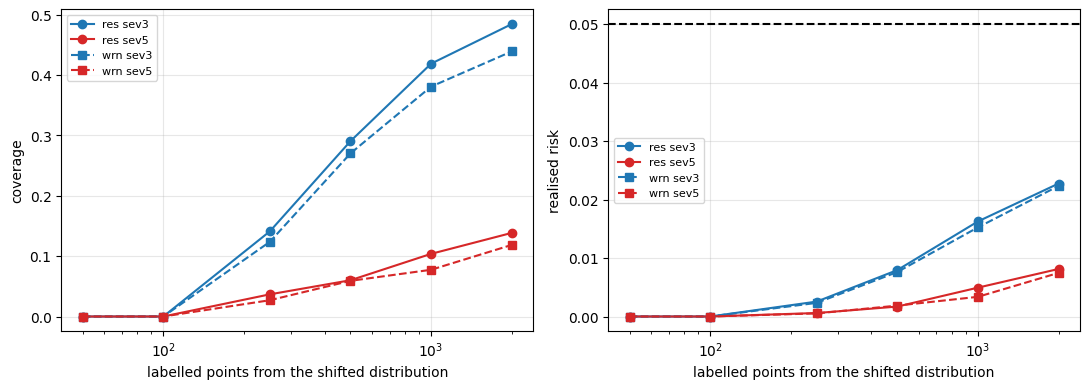

In [5]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
for a,ls in (("res","o-"),("wrn","s--")):
    for sev,col in ((3,"tab:blue"),(5,"tab:red")):
        ax[0].plot(BUD,[out[(a,sev,n)][1] for n in BUD],ls,c=col,label=f"{a} sev{sev}")
        ax[1].plot(BUD,[out[(a,sev,n)][0] for n in BUD],ls,c=col,label=f"{a} sev{sev}")
for i,(t,y0) in enumerate([("coverage",None),("realised risk",TG)]):
    ax[i].set_xscale("log"); ax[i].set_xlabel("labelled points from the shifted distribution")
    ax[i].set_ylabel(t); ax[i].grid(alpha=.3); ax[i].legend(fontsize=8)
    if y0: ax[i].axhline(y0,ls="--",c="k")
plt.tight_layout(); plt.show()

## What this settles

If violation now sits at or below 10% while coverage climbs with n, you can state
the constructive half of the paper properly: a distribution free procedure with a
few hundred labels from the deployment condition delivers the target risk with
finite sample validity, which no label free method does at any budget.

That is the last experiment. Write the paper.